# OSS Maintenance Model Training

This notebook is the primary, thesis-visible workflow for the fixed Logistic Regression and XGBoost artifact bundle used by OSS Risk Radar. Python package modules own the implementation; this notebook exposes the data, features, split, evaluation, and artifact export path end to end. The main research framing is early warning before inactivity or archival, so archived repositories may enter the sampling frame while already-archived observation rows are excluded from model fitting.

## Python Module Map

The notebook is intentionally small because the reusable Python package owns the implementation. These are the main scripts/modules behind each visible step.

| Notebook step | Python module | What it owns |
| --- | --- | --- |
| 1. Problem and label definition | `app.training.maintenance_dataset.labels` | Converts historical activity windows into the `label_inactive_12m` target. |
| 2. GHArchive and data preparation | `app.training.maintenance_dataset.pipeline` | Builds training snapshots from seed repositories, GHArchive event windows, repository metadata, and scorecard data. |
| 2. GHArchive and data preparation | `app.training.maintenance_dataset.events` | Parses GHArchive event JSON into normalized repository activity events. |
| 2. GHArchive and data preparation | `app.training.maintenance_dataset.storage` | Reads local hourly GHArchive files and feeds the dataset builder. |
| 3. Feature engineering | `app.training.maintenance_dataset.features` | Aggregates historical event windows into repository-level training signals. |
| 3. Feature engineering | `app.modeling.features` | Converts dependency/repository snapshots into the stable model feature vector used by training and runtime scoring. |
| 4. Time-aware split | `app.training.datasets` | Loads snapshots, filters labeled rows, and creates chronological train/validation/test splits. |
| 5. Logistic Regression training | `app.modeling.baseline` | Trains and serializes the Logistic Regression baseline. |
| 5. XGBoost training | `app.modeling.xgboost_model` | Trains and serializes the XGBoost model. |
| 5. Evaluation | `app.training.evaluation` | Computes model metrics and model quality summaries. |
| 5. Calibration | `app.training.calibration` | Builds calibration bins for artifact metadata and dashboard plots. |
| 6. Artifact export | `app.training.artifact_export` | Computes the Go-compatible dataset hash, trains full-history and cold-start Logistic Regression/XGBoost artifacts, writes run JSON files, and updates `latest-run.json`. |
| Runtime scoring | `app.scoring.model` | Loads staged artifacts and scores submitted GitHub repositories/dependencies with the trained models. |
| Internal API bridge | `app.api.routes` | Exposes internal model scoring and feature extraction endpoints to the Go API. |

## 1. Problem And Label Definition

The target is `label_inactive_12m`: whether a repository becomes inactive or archived during the 12 months after an observation date. Labels come from historical GHArchive coverage, not from user-submitted GitHub URLs. Seed buckets such as active, dormant, or archived are sampling provenance only. Runtime analysis scores submitted repositories with the staged artifacts exported at the end of this notebook.

In [11]:
from __future__ import annotations

# Parameters. Papermill overrides this cell during headless training runs.
dataset_path = "tmp/training/snapshots.json"
runs_dir = "tmp/training/runs"
latest_run_path = "tmp/training/latest-run.json"
model_names = ["logistic-regression-full-history", "xgboost-full-history", "logistic-regression-cold-start", "xgboost-cold-start"]
train_ratio = 0.75
validation_ratio = 0.15
calibration_bins = 10
label_horizon_months = 12
force = False
export_artifacts = True
use_smoke_dataset = False


In [12]:
import json
import sys
from datetime import date
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "mltraining" / "scoring" / "app").exists():
            return candidate
    raise RuntimeError("could not locate repository root from notebook working directory")


def resolve_repo_path(value: str | Path) -> Path:
    candidate = Path(value)
    return candidate if candidate.is_absolute() else REPO_ROOT / candidate


def add_months(value: date, months: int) -> date:
    month_index = value.month - 1 + months
    year = value.year + month_index // 12
    month = month_index % 12 + 1
    day = min(value.day, 28)
    return date(year, month, day)


def infer_latest_complete_gharchive_date(source_dir: Path | None = None) -> date | None:
    source_dir = source_dir or (REPO_ROOT / "tmp" / "gharchive")
    if not source_dir.exists() or not source_dir.is_dir():
        return None
    hours_by_date: dict[str, set[int]] = {}
    for item in source_dir.iterdir():
        if not item.is_file() or item.suffix != ".gz":
            continue
        stem = item.name.removesuffix(".json.gz")
        date_part, _, hour_part = stem.rpartition("-")
        if not date_part or not hour_part.isdigit():
            continue
        hours_by_date.setdefault(date_part, set()).add(int(hour_part))
    complete_dates = sorted(day for day, hours in hours_by_date.items() if len(hours) == 24)
    return date.fromisoformat(complete_dates[-1]) if complete_dates else None


REPO_ROOT = find_repo_root(Path.cwd())
SCORING_ROOT = REPO_ROOT / "mltraining" / "scoring"
if str(SCORING_ROOT) not in sys.path:
    sys.path.insert(0, str(SCORING_ROOT))
importlib.invalidate_caches()

import app.modeling.features as modeling_features_module
import app.training.datasets as datasets_module
import app.training.pipeline as pipeline_module
import app.training.artifact_export as artifact_export_module

# Interactive notebook kernels cache imports across edits. Reload local modules so the notebook
# always uses the workspace implementation, not a stale import from an earlier cell run.
modeling_features_module = importlib.reload(modeling_features_module)
datasets_module = importlib.reload(datasets_module)
pipeline_module = importlib.reload(pipeline_module)
artifact_export_module = importlib.reload(artifact_export_module)

ArtifactExportConfig = artifact_export_module.ArtifactExportConfig
best_run = artifact_export_module.best_run
build_artifact_runs = artifact_export_module.build_artifact_runs
compute_go_dataset_hash = artifact_export_module.compute_go_dataset_hash
load_raw_snapshot_items = artifact_export_module.load_raw_snapshot_items
prepare_artifact_export = artifact_export_module.prepare_artifact_export
write_artifact_bundle = artifact_export_module.write_artifact_bundle

build_dataset = datasets_module.build_dataset
labeled_rows = datasets_module.labeled_rows
load_snapshots_from_uri = datasets_module.load_snapshots_from_uri
time_aware_split = datasets_module.time_aware_split

pd.set_option("display.max_columns", 120)


## 2. GHArchive And Data Preparation

The dataset is built before training from filtered hourly GHArchive observations. The notebook reports the latest complete local GHArchive coverage day when tmp/gharchive is available, then checks that the prepared snapshot file is labeled. A smoke dataset is available only for automated notebook checks and writes under tmp/notebooks.


In [13]:
def fixture_snapshot(index: int, observed_at: str, inactive: bool) -> dict:
    stale_days = 650 if inactive else 20
    contributors = 1 if inactive else 6
    concentration = 0.9 if inactive else 0.3
    return {
        "analysis_id": "notebook_fixture",
        "observed_at": observed_at,
        "label_inactive_12m": inactive,
        "dependency": {
            "dependency_id": f"fixture_{index}",
            "package_name": f"fixture/project-{index}",
            "package_version": "repository-snapshot",
            "ecosystem": "github",
            "direct": True,
            "repository": {
                "full_name": f"fixture/project-{index}",
                "url": f"https://github.com/fixture/project-{index}",
                "default_branch": "main",
                "archived": False,
                "stars": 1000 + index,
                "forks": 100,
                "open_issues": 40,
                "last_push_age_days": stale_days,
                "last_release_age_days": stale_days + 30,
                "release_cadence_days": stale_days + 30,
                "recent_contributors_90d": contributors,
                "contributor_concentration": concentration,
                "open_issue_growth_90d": 0.4 if inactive else -0.1,
                "pr_response_median_days": 35 if inactive else 2,
            },
            "historical_features": {
                "commits_30d": 0 if inactive else 18,
                "commits_90d": 1 if inactive else 72,
                "commits_365d": 8 if inactive else 260,
                "active_commit_months_365d": 2 if inactive else 11,
                "days_since_last_commit": stale_days,
                "contributors_90d": contributors,
                "contributors_365d": 2 if inactive else 24,
                "new_contributors_365d": 0 if inactive else 6,
                "top1_contributor_commit_share_365d": 0.88 if inactive else 0.32,
                "top2_contributor_commit_share_365d": 0.96 if inactive else 0.49,
                "contributor_concentration_index": concentration,
                "maintainer_concentration_flag": 1 if inactive else 0,
                "opened_issues_90d": 22 if inactive else 9,
                "closed_issues_90d": 3 if inactive else 12,
                "issue_closure_ratio_90d": 0.14 if inactive else 1.33,
                "issue_backlog_growth_90d": 0.45 if inactive else -0.18,
                "stale_open_issues_count_at_obs": 31 if inactive else 4,
                "issue_first_response_median_days_365d": 21 if inactive else 2,
                "issue_resolution_median_days_365d": 90 if inactive else 12,
                "stale_issue_share_at_obs": 0.68 if inactive else 0.08,
                "opened_prs_90d": 4 if inactive else 28,
                "merged_prs_90d": 0 if inactive else 22,
                "closed_unmerged_prs_90d": 3 if inactive else 4,
                "pr_merge_ratio_90d": 0.0 if inactive else 0.79,
                "stale_open_prs_count_at_obs": 9 if inactive else 1,
                "pr_response_median_days_365d": 35 if inactive else 2,
                "pr_merge_latency_median_days_365d": 48 if inactive else 3,
                "releases_365d": 0 if inactive else 8,
                "days_since_last_release": stale_days + 30,
                "versions_published_365d": 0 if inactive else 8,
                "package_age_days": 1800 + index,
                "repo_age_days": 1900 + index,
                "stars_total_at_obs": 1000 + index,
                "forks_total_at_obs": 100,
                "dependency_count_at_obs": 0,
                "popularity_tier_at_obs": 2,
                "repo_archived_at_obs": 0,
                "has_recent_release_flag": 0 if inactive else 1,
                "has_recent_pr_merge_flag": 0 if inactive else 1,
                "activity_drop_365d_vs_prev_365d": 120 if inactive else -10,
                "contributors_drop_365d_vs_prev_365d": 8 if inactive else -2,
                "release_gap_risk": 1 if inactive else 0,
                "concentration_risk_score": 0.84 if inactive else 0.18,
            },
            "scorecard": {
                "score": 4.5 if inactive else 8.8,
                "checks": [
                    {"name": "Branch-Protection", "score": 4 if inactive else 9, "reason": "fixture"},
                    {"name": "Binary-Artifacts", "score": 5 if inactive else 9, "reason": "fixture"},
                ],
            },
        },
        "sampling": {"seed_source": "notebook-smoke:active" if not inactive else "notebook-smoke:pre-archival"},
        "label_components": {"archived_by_t_plus_12m": inactive and index % 2 == 0},
    }


def write_smoke_dataset(target: Path) -> list[dict]:
    rows = [
        ("2023-01-01T00:00:00Z", False),
        ("2023-02-01T00:00:00Z", True),
        ("2023-03-01T00:00:00Z", False),
        ("2023-04-01T00:00:00Z", True),
        ("2023-05-01T00:00:00Z", False),
        ("2023-06-01T00:00:00Z", True),
        ("2023-07-01T00:00:00Z", False),
        ("2023-08-01T00:00:00Z", True),
    ]
    snapshots = [fixture_snapshot(index, observed_at, inactive) for index, (observed_at, inactive) in enumerate(rows, start=1)]
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_text(json.dumps({"snapshots": snapshots}, indent=2) + "\n", encoding="utf-8")
    return snapshots


resolved_dataset_path = resolve_repo_path(dataset_path)
if use_smoke_dataset:
    raw_snapshot_items = write_smoke_dataset(resolved_dataset_path)
else:
    raw_snapshot_items = load_raw_snapshot_items(resolved_dataset_path)

snapshots = load_snapshots_from_uri(str(resolved_dataset_path))
if not any(snapshot.label_inactive_12m is not None for snapshot in snapshots):
    raise ValueError("training snapshots contain no labels; build the historical dataset first")

observed_dates = [pd.Timestamp(snapshot.observed_at).date() for snapshot in snapshots]
latest_complete_coverage = infer_latest_complete_gharchive_date()
safe_label_cutoff = add_months(latest_complete_coverage, -label_horizon_months) if latest_complete_coverage else None
dataset_hash = compute_go_dataset_hash(raw_snapshot_items)
already_archived_at_obs = sum(
    1 for item in raw_snapshot_items
    if float((item.get("dependency") or {}).get("historical_features", {}).get("repo_archived_at_obs", 0) or 0) >= 1
)
pre_archival_snapshots = len(raw_snapshot_items) - already_archived_at_obs
archived_by_horizon = sum(1 for item in raw_snapshot_items if (item.get("label_components") or {}).get("archived_by_t_plus_12m"))
coverage_frame = pd.DataFrame([
    {
        "dataset_path": str(resolved_dataset_path),
        "snapshots": len(snapshots),
        "labeled_snapshots": sum(1 for snapshot in snapshots if snapshot.label_inactive_12m is not None),
        "unlabeled_snapshots": sum(1 for snapshot in snapshots if snapshot.label_inactive_12m is None),
        "pre_archival_snapshots": pre_archival_snapshots,
        "already_archived_at_observation": already_archived_at_obs,
        "archived_by_t_plus_12m": archived_by_horizon,
        "observed_start": min(observed_dates).isoformat() if observed_dates else "",
        "observed_end": max(observed_dates).isoformat() if observed_dates else "",
        "latest_complete_gharchive_date": latest_complete_coverage.isoformat() if latest_complete_coverage else "not detected",
        "safe_label_horizon_cutoff": safe_label_cutoff.isoformat() if safe_label_cutoff else "not detected",
        "label_horizon_months": label_horizon_months,
        "dataset_hash": dataset_hash,
    }
])
display(coverage_frame)

seed_distribution = pd.Series(
    [(item.get("sampling") or {}).get("seed_source", "unknown") for item in raw_snapshot_items],
    name="snapshots",
).value_counts().rename_axis("seed_source").reset_index()
label_distribution = pd.Series(
    [item.get("label_inactive_12m") for item in raw_snapshot_items],
    name="snapshots",
).value_counts(dropna=False).rename_axis("label_inactive_12m").reset_index()
display(seed_distribution)
display(label_distribution)


,dataset_path,snapshots,labeled_snapshots,unlabeled_snapshots,pre_archival_snapshots,already_archived_at_observation,archived_by_t_plus_12m,observed_start,observed_end,latest_complete_gharchive_date,safe_label_horizon_cutoff,label_horizon_months,dataset_hash
0,c:\Neuer Ordner\oss-risk-radar\tmp\training\sn...,452,366,86,452,0,0,2023-01-01,2026-06-09,2026-06-07,2025-06-07,12,cbb2f6ec483efe8baf9cd08159f29bb1b7f3654fd3aaa4...


,seed_source,count
0,unknown,452


,label_inactive_12m,count
0,False,285
1,None,86
2,True,81


## 3. Feature Engineering

Feature rows are derived only from observation-time repository and historical GHArchive coverage signals. OpenSSF Scorecard remains a separate security posture input and is not part of the inactivity model feature vector. The future inactivity label is kept separate and used only as the supervised target.

In [14]:
dataset = build_dataset(snapshots, exclude_already_archived_at_observation=True)
rows = labeled_rows(dataset.rows)
if len(rows) < 3:
    raise ValueError("at least three labeled rows are required for time-aware model training")

feature_frame = pd.DataFrame([
    {
        **row.feature_values,
        "label_inactive_12m": row.label_inactive_12m,
        "observed_at": row.observed_at,
        "package_name": row.package_name,
    }
    for row in rows
])
feature_frame.head()


,has_repository_mapping,is_direct_dependency,last_push_age_days,last_release_age_days,release_cadence_days,recent_contributors_90d,contributor_concentration,open_issue_growth_90d,pr_response_median_days,stars_log1p,forks_log1p,open_issues_log1p,ecosystem_npm,ecosystem_pypi,ecosystem_go,ecosystem_maven,ecosystem_other,commits_30d,commits_90d,commits_365d,active_commit_months_365d,days_since_last_commit,contributors_90d,contributors_365d,new_contributors_365d,top1_contributor_commit_share_365d,top2_contributor_commit_share_365d,contributor_concentration_index,maintainer_concentration_flag,opened_issues_90d,closed_issues_90d,issue_closure_ratio_90d,issue_backlog_growth_90d,stale_open_issues_count_at_obs,opened_prs_90d,merged_prs_90d,closed_unmerged_prs_90d,pr_merge_ratio_90d,stale_open_prs_count_at_obs,releases_365d,days_since_last_release,versions_published_365d,package_age_days,repo_age_days,stars_total_at_obs,forks_total_at_obs,dependency_count_at_obs,popularity_tier_at_obs,has_recent_release_flag,has_recent_pr_merge_flag,activity_drop_365d_vs_prev_365d,contributors_drop_365d_vs_prev_365d,release_gap_risk,concentration_risk_score,issue_first_response_median_days_365d,issue_resolution_median_days_365d,stale_issue_share_at_obs,pr_response_median_days_365d,pr_merge_latency_median_days_365d,label_inactive_12m,observed_at,package_name
0,1.0,1.0,653.0,4042.0,0.0,0.0,0.000000,0.000000,0.000000,7.780721,7.626570,4.418841,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,653.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,82.0,0.0,0.0,0.0,0.000000,14.0,0.0,4042.0,0.0,4042.0,4042.0,2393.0,2051.0,0.0,2.0,0.0,0.0,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1,2023-01-01 00:00:00+00:00,adobe/brackets
1,1.0,1.0,263.0,264.0,4478.0,0.0,1.000000,0.000000,0.851076,7.161622,6.908755,3.258097,0.0,0.0,0.0,0.0,1.0,0.0,0.0,8.0,2.0,263.0,0.0,1.0,1.0,1.000000,1.000000,1.000000,1.0,0.0,0.0,0.000000,0.000000,25.0,0.0,0.0,1.0,0.000000,16.0,1.0,264.0,0.0,4742.0,4742.0,1288.0,1000.0,0.0,2.0,1.0,0.0,0.859649,0.500000,0.029477,1.000000,1789.416470,0.258692,1.000000,0.851076,45.871389,1,2023-01-01 00:00:00+00:00,angular/angular.js
2,1.0,1.0,7.0,17.0,26.0,10.0,0.224822,0.075138,0.418090,9.955606,8.840725,7.574045,0.0,0.0,0.0,0.0,1.0,356.0,1071.0,4786.0,12.0,7.0,10.0,13.0,4.0,0.224822,0.410573,0.149109,0.0,357.0,221.0,0.619048,0.075138,1777.0,649.0,66.0,437.0,0.101695,750.0,192.0,17.0,0.0,3026.0,3026.0,21069.0,6909.0,0.0,2.0,1.0,1.0,0.134695,0.187500,0.094444,0.246830,1.426794,64.766782,0.913155,0.418090,0.005278,0,2023-01-01 00:00:00+00:00,angular/angular
3,1.0,1.0,4.0,25.0,69.0,17.0,0.250177,-0.014756,0.073142,9.292473,8.364974,6.767343,0.0,0.0,0.0,0.0,1.0,78.0,361.0,1411.0,12.0,4.0,17.0,20.0,3.0,0.250177,0.457123,0.150352,0.0,224.0,237.0,1.058036,-0.014756,801.0,431.0,325.0,57.0,0.754060,545.0,50.0,25.0,0.0,3952.0,3952.0,10855.0,4293.0,0.0,2.0,1.0,1.0,0.062458,0.130435,0.138889,0.271601,0.004155,7.606481,0.922811,0.073142,0.916626,0,2023-01-01 00:00:00+00:00,ansible/ansible
4,1.0,1.0,0.0,12.0,20.0,16.0,0.459277,0.097264,0.292847,9.140025,8.501876,7.275865,0.0,0.0,0.0,0.0,1.0,275.0,1131.0,6360.0,12.0,0.0,16.0,24.0,6.0,0.459277,0.630660,0.264858,0.0,421.0,293.0,0.695962,0.097264,1206.0,1021.0,798.0,143.0,0.781587,542.0,1006.0,12.0,0.0,2819.0,2819.0,9320.0,4923.0,0.0,2.0,1.0,1.0,-0.191681,0.040000,0.066667,0.454670,0.514572,14.807002,0.835180,0.292847,0.826383,0,2023-01-01 00:00:00+00:00,apache/airflow


In [15]:
feature_groups = {
    "activity": [
        "commits_30d", "commits_90d", "commits_365d", "active_commit_months_365d", "days_since_last_commit",
        "has_recent_pr_merge_flag", "activity_drop_365d_vs_prev_365d",
    ],
    "responsiveness": [
        "pr_response_median_days", "pr_response_median_days_365d", "pr_merge_latency_median_days_365d",
        "issue_first_response_median_days_365d", "issue_resolution_median_days_365d",
    ],
    "backlog": [
        "opened_issues_90d", "closed_issues_90d", "issue_closure_ratio_90d", "issue_backlog_growth_90d",
        "stale_open_issues_count_at_obs", "stale_open_prs_count_at_obs", "stale_issue_share_at_obs",
    ],
    "contributor_resilience": [
        "contributors_90d", "contributors_365d", "new_contributors_365d", "top1_contributor_commit_share_365d",
        "top2_contributor_commit_share_365d", "contributor_concentration_index", "maintainer_concentration_flag",
        "contributors_drop_365d_vs_prev_365d", "concentration_risk_score",
    ],
    "release_sustainability": [
        "releases_365d", "days_since_last_release", "versions_published_365d", "package_age_days", "repo_age_days",
        "has_recent_release_flag", "release_gap_risk",
    ],
    "popularity_context": [
        "stars_log1p", "forks_log1p", "open_issues_log1p", "stars_total_at_obs", "forks_total_at_obs",
        "dependency_count_at_obs", "popularity_tier_at_obs",
    ],
}

feature_group_frame = pd.DataFrame([
    {
        "concept": concept,
        "features_present": len([feature for feature in features if feature in dataset.feature_names]),
        "features_missing": ", ".join(feature for feature in features if feature not in dataset.feature_names),
        "mean_abs_value": round(float(feature_frame[[feature for feature in features if feature in feature_frame.columns]].abs().mean().mean()), 6)
        if any(feature in feature_frame.columns for feature in features)
        else 0.0,
    }
    for concept, features in feature_groups.items()
])
feature_group_frame


,concept,features_present,features_missing,mean_abs_value
0,activity,7,,1283.321458
1,responsiveness,5,,52.978100
2,backlog,7,,291.636450
3,contributor_resilience,9,,5.103397
4,release_sustainability,7,,1131.588705
5,popularity_context,7,,2931.929804


## 4. Time-Aware Train/Validation/Test Split

Rows are ordered by observation date. Training uses the earliest slice, validation calibrates/selects the threshold, and the final slice is held out for reported metrics.

In [16]:
split = time_aware_split(rows, train_ratio=train_ratio, validation_ratio=validation_ratio)
if min(len(split.train), len(split.validation), len(split.test)) <= 0:
    raise ValueError("time-aware split produced an empty train, validation, or test partition")

split_frame = pd.DataFrame([
    {"split": "train", "rows": len(split.train), "start": split.train[0].observed_at, "end": split.train[-1].observed_at},
    {"split": "validation", "rows": len(split.validation), "start": split.validation[0].observed_at, "end": split.validation[-1].observed_at},
    {"split": "test", "rows": len(split.test), "start": split.test[0].observed_at, "end": split.test[-1].observed_at},
])
split_frame


,split,rows,start,end
0,train,274,2023-01-01 00:00:00+00:00,2024-07-01 00:00:00+00:00
1,validation,55,2024-07-01 00:00:00+00:00,2025-01-01 00:00:00+00:00
2,test,37,2025-01-01 00:00:00+00:00,2025-01-01 00:00:00+00:00


## 5. Logistic Regression And XGBoost Training/Evaluation

Both models use the same feature table and split parameters. The helper below builds the exact run artifacts that will be exported in the final step, so the displayed metrics and staged JSON files come from the same execution.

In [17]:
export_config = ArtifactExportConfig(
    dataset_path=resolved_dataset_path,
    runs_dir=resolve_repo_path(runs_dir),
    latest_run_path=resolve_repo_path(latest_run_path),
    model_names=model_names,
    train_ratio=train_ratio,
    validation_ratio=validation_ratio,
    calibration_bins=calibration_bins,
    force=force,
    verbose=True,
)
export_plan = prepare_artifact_export(export_config)
artifact_runs = build_artifact_runs(export_config, export_plan)

metrics_frame = pd.DataFrame([
    {
        "model": run["modelName"],
        "version": run["modelVersion"],
        "status": run["status"],
        "train_rows": run["splitSummary"]["trainRows"],
        "validation_rows": run["splitSummary"]["validationRows"],
        "test_rows": run["splitSummary"]["testRows"],
        "roc_auc": run["metrics"]["rocAuc"],
        "brier_score": run["metrics"]["brierScore"],
        "quality_score": run["metrics"]["qualityScore"],
    }
    for run in artifact_runs
])
metrics_frame


reuse logistic-regression-full-history: C:\Neuer Ordner\oss-risk-radar\tmp\training\runs\20260609T205807809883Z-logistic-regression-full-history-cbb2f6ec483e.json
reuse xgboost-full-history: C:\Neuer Ordner\oss-risk-radar\tmp\training\runs\20260609T205808558240Z-xgboost-full-history-cbb2f6ec483e.json
reuse logistic-regression-cold-start: C:\Neuer Ordner\oss-risk-radar\tmp\training\runs\20260609T205809378806Z-logistic-regression-cold-start-cbb2f6ec483e.json
reuse xgboost-cold-start: C:\Neuer Ordner\oss-risk-radar\tmp\training\runs\20260609T205809458516Z-xgboost-cold-start-cbb2f6ec483e.json


,model,version,status,train_rows,validation_rows,test_rows,roc_auc,brier_score,quality_score
0,logistic-regression-full-history,0.4.0,completed,274,55,37,0.997312,0.027176,0.916765
1,xgboost-full-history,0.2.0,completed,274,55,37,1.000000,0.007634,0.977526
2,logistic-regression-cold-start,0.4.0,completed,274,55,37,1.000000,0.027076,0.920286
3,xgboost-cold-start,0.2.0,completed,274,55,37,0.916667,0.043085,0.773155


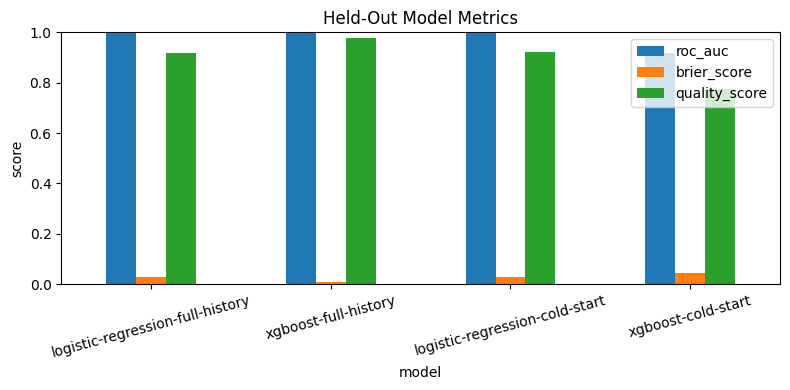

In [18]:
plot_frame = metrics_frame.set_index("model")[["roc_auc", "brier_score", "quality_score"]]
axis = plot_frame.plot(kind="bar", figsize=(8, 4), rot=15, title="Held-Out Model Metrics")
axis.set_ylim(0, 1)
axis.set_ylabel("score")
plt.tight_layout()


## 6. Artifact Export And Staging Notes

This is the artifact boundary used by the application. The notebook writes completed Logistic Regression and XGBoost run JSON files plus a `latest-run.json` pointer; deployment promotion remains a separate staging step.

In [19]:
if export_artifacts:
    latest = write_artifact_bundle(artifact_runs, export_plan.latest_run_path)
else:
    latest = best_run(artifact_runs)

export_frame = pd.DataFrame([
    {
        "model": run["modelName"],
        "artifact_path": run["artifactPath"],
        "dataset_hash": run["datasetHash"],
        "quality_score": run["metrics"]["qualityScore"],
        "exported": bool(export_artifacts),
        "latest_pointer": str(export_plan.latest_run_path) if run["modelName"] == latest["modelName"] else "",
    }
    for run in artifact_runs
])
export_frame


,model,artifact_path,dataset_hash,quality_score,exported,latest_pointer
0,logistic-regression-full-history,C:\Neuer Ordner\oss-risk-radar\tmp\training\ru...,cbb2f6ec483efe8baf9cd08159f29bb1b7f3654fd3aaa4...,0.916765,True,
1,xgboost-full-history,C:\Neuer Ordner\oss-risk-radar\tmp\training\ru...,cbb2f6ec483efe8baf9cd08159f29bb1b7f3654fd3aaa4...,0.977526,True,c:\Neuer Ordner\oss-risk-radar\tmp\training\la...
2,logistic-regression-cold-start,C:\Neuer Ordner\oss-risk-radar\tmp\training\ru...,cbb2f6ec483efe8baf9cd08159f29bb1b7f3654fd3aaa4...,0.920286,True,
3,xgboost-cold-start,C:\Neuer Ordner\oss-risk-radar\tmp\training\ru...,cbb2f6ec483efe8baf9cd08159f29bb1b7f3654fd3aaa4...,0.773155,True,


In [20]:
print("Promote staged artifacts after review:")
print("npm run ml:stage-training")


Promote staged artifacts after review:
npm run ml:stage-training
